# Projeto: Previsão de Preços de Imóveis

**Descrição:** Projeto de ciência de dados com previsão de preços de imóveis na Califórnia. Os dados utilizados no treinamento da regressão são de 1990 e não devem ser utilizados para fins comerciais nos tempos atuais.

**Autor:** Ivan Luís Duarte  
**LinkedIn:** [ivanluisduarte](https://www.linkedin.com/in/ivanluisduarte/)  
**GitHub:** [ivanluisduarte](https://github.com/ivanluisduarte)  
**Data de Criação:** 2025-03-10  
**Licença:** MIT

# Nota Importante
O propósito deste notebook é encontrar o melhor modelo para os dados Sem Outliers. Já trabalhamos com praticamente tudo que era possível com LinearRegression. Vamos agora utilizar ElasticNet como regressor e tentar encontrar uma solução melhor que aquela que já encontramos na etapa anterior.

Vamos combinar opções de hiperparâmetros para regularizar os coeficientes das diversas features polinomais criadas na etapa anterior e encontrar um novo modelo melhor que o que temos até o momento.

---

Leia o arquivo [README.md](../README.md) para detalhes sobre a base o projeto.

Leia o arquivo de [01_dicionario_de_dados.md](../referencias/01_dicionario_de_dados.md) para detalhes sobre a base.

Ao importar esse arquivo [src.graficos](./src/graficos.py), em tema seaborn é aplicado.

# Imports e configurações

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pprint import pprint
import seaborn as sns


from sklearn.compose import ColumnTransformer # constrói um pipeline para diferentes colunas

from sklearn.exceptions import ConvergenceWarning

from sklearn.linear_model import (
    ElasticNet, # uma combinação de Lasso e Ridge para regularização de features
    LinearRegression, # modelo de regressão linear com coeficientes estimados usando o método dos mínimos quadrados
)
from sklearn.pipeline import Pipeline # enfileira diferentes procedimentos
from sklearn.preprocessing import (  # Módulo de pré-processamento de dados
    OneHotEncoder,       # Codifica variáveis categóricas nominais, transformando-as em uma matriz binária (uma coluna para cada categoria)
    OrdinalEncoder,      # Codifica variáveis categóricas ordinais, convertendo categorias em inteiros com base na ordem
    PolynomialFeatures,  # Cria features polinomiais e de multiplicação entre elas.
    PowerTransformer,    # Aplica uma transformação de potência para estabilizar a variância e tornar os dados mais gaussianos
    QuantileTransformer, # Realiza uma transformação baseada em quantis, escalando os dados para uma distribuição uniforme ou normal
    # RobustScaler,        # Normaliza os dados utilizando estatísticas robustas (mediana e intervalo interquartil), útil para dados com outliers
    StandardScaler,      # Normaliza os dados para que tenham média zero e desvio padrão um, útil para dados normalmente distribuídos
)

import warnings


from src.auxiliares import (
    fnc_dataframe_coeficientes, # função que combina os coeficientes de um gridsearch com os nomes das features em um DataFrame
    fnc_describe_numericas_personalizado, # função que retorna um dataframe com o describe() de variáveis numéricas enriquecido com colunas de tipo, ausência, variabilidade, outliers e normalidade
    fnc_exibir_dataframe_resultados, # função que exibe um DataFrame estilizado no notebook ou um DataFrame simples no console
)
from src.config import (
    DADOS_X_TEST,
    DADOS_X_TRAIN,
    DADOS_X_VALIDATION,
    DADOS_Y_TEST,
    DADOS_Y_TRAIN,
    DADOS_Y_VALIDATION,
)
from src.graficos import (
    PALETTE_TEMPERATURA,
    plot_coeficientes, # função para plotar um gráfico de barras horizontais dos coeficientes de um modelo
    plot_comparar_metricas_modelos, # função para plotar boxplots de diferentes modelos para diferentes méticas de um dataframe de resultado
    plot_residuos_estimador, # função que plota 3 gráficos de resíduos para um estimador, um histograma e dois de dispersão
)
from src.models import (
    fnc_grid_search_cv_regressor, # função para planejar modelos de regressão validação cruzada e grid search
    fnc_treinar_e_validar_modelos_regressao, # função para treinar modelos de regressão com validação cruzada usando um dicionário de regressores
)

In [2]:
pd.options.display.max_rows = 15
pd.options.display.max_columns = None
pd.options.display.float_format = '{:.2f}'.format

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Modelagem para melhoria do modelo da etapa 4

## Carregando os arquivos de treino/teste e validação criados na etapa 2

Origem: [01-ild-eda.ipynb](01-ild-eda.ipynb)

- `median_income`: renda mediana no grupo de blocos (em dezenas de milhares de dólares)
- `housing_median_age`: idade mediana das casas no grupo de blocos
- `total_rooms`: número cômodos no grupo de blocos
- `total_bedrooms`: número de quartos no grupo de blocos
- `population`: população do grupo de blocos
- `households`: domicílios no grupo de blocos
- `latitude`: latitude do grupo de blocos
- `longitude`: longitude do grupo de blocos
- `ocean_proximity`: proximidade do oceano
  - `NEAR BAY`: perto da baía
  - `<1H OCEAN`: a menos de uma hora do oceano
  - `INLAND`: no interior
  - `NEAR OCEAN`: perto do oceano
- `median_house_value`: valor mediano das casas no grupo de blocos (em dólares)
- `median_income_cat`: categorias baseadas no valor da mediana do salário anual -> `median_income`
- `housing_median_age_cat`: categorias baseadas no valor da mediana das idades das casas -> `housing_median_age`
- `population_cat`: categorias baseadas no tamanho da população -> `population`
- `rooms_per_household`: `total_rooms` / `households`
- `population_per_household`: `population` / `households`
- `bedrooms_per_room`: `total_bedrooms` / `total_rooms`

In [3]:
# dados já separados como X e y de treino, teste e validação
X_train = pd.read_parquet(DADOS_X_TRAIN)
y_train = pd.read_parquet(DADOS_Y_TRAIN)

print('X_train.shape', X_train.shape)
print('y_train.shape', y_train.shape)

X_train.shape (12862, 15)
y_train.shape (12862, 1)


In [4]:
display(
    X_train.head(1),
    y_train.head(1),
)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_income_cat,housing_median_age_cat,population_cat,rooms_per_household,population_per_household,bedrooms_per_room
4816,-118.28,33.91,41,620,133,642,162,2.65,<1H OCEAN,1.5 <= x < 3,40 <= x,500 <= x < 1000,3.83,3.96,0.21


,median_house_value
4816,159600


## Definindo as estratégias para os modelos
Vamos manter a estratégia ganhadora do GRID SEARCH da etapa anterior e vamos experimentar regularizar os coeficiente das diversas features.

In [ ]:
coluna_target = ['median_house_value']

# define as colunas a serem transformadas
colunas_one_hot_encoder = ['ocean_proximity',]
colunas_ordinal_encoder = ['median_income_cat', 'housing_median_age_cat', 'population_cat',]
colunas_standard_scaler_poly = ['longitude', 'latitude', 'housing_median_age']
colunas_power_tranformer_poly = X_train.columns.difference( # colunas restantes com outliers
    colunas_one_hot_encoder + colunas_ordinal_encoder + colunas_standard_scaler_poly
).to_list()


preprocessamento_categoricas = ColumnTransformer(
    transformers=[
        ('one_hot_encoder', OneHotEncoder(drop='first'), colunas_one_hot_encoder), # drop='first' para evitar a dummy variable trap
        ('ordinal_encoder', OrdinalEncoder(categories='auto'), colunas_ordinal_encoder), # categories='auto' para usar as categorias do dataframe
    ],
    remainder='passthrough', # mantém as colunas que não foram transformadas
)


# enfileira uma transformação depois de outra
pipeline_standard_poly = Pipeline(
    steps=(
        ('standard_scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=True)),
    ),
)

# enfileira uma transformação depois de outra
pipeline_power_poly = Pipeline(
    steps=(
        ('power_transformer', PowerTransformer(method='box-cox')), # box-cox só funciona para números positivos
        ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=True)),
    ),
)

# define o preprocessamento das colunas - o preprocessamento é feito em ordem
preprocessamento_polinomiais = ColumnTransformer(
    transformers=preprocessamento_categoricas.transformers + [
        ('standard_scaler_poly', pipeline_standard_poly, colunas_standard_scaler_poly),
        ('power_transformer_poly', pipeline_power_poly, colunas_power_tranformer_poly),
    ],
)



target_transfomer = QuantileTransformer(output_distribution='normal')



# algorítmos de avaliação de modelos de regressão a utilizar nessa análise - https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter
dct_metricas_modelos = {
        # 'd2_absolute_error_score'            : 'd2ae',  # melhor = 1.0 -> metrics.d2_absolute_error_score
        # 'explained_variance'                 : 'evs',   # melhor = 1.0 -> metrics.explained_variance_score
        # 'neg_max_error'                      : 'maxe',  # melhor = 0.0 -> metrics.max_error
        'neg_mean_absolute_error'            : 'mae',   # melhor = 0.0 -> metrics.mean_absolute_error
        # 'neg_mean_absolute_percentage_error' : 'mape',  # melhor = 0.0 -> metrics.mean_absolute_percentage_error
        # 'neg_mean_gamma_deviance'            : 'mgd',   # melhor = 0.0 -> metrics.mean_gamma_deviance
        # 'neg_mean_poisson_deviance'          : 'mpd',   # melhor = 0.0 -> metrics.mean_poisson_deviance
        # 'neg_mean_squared_error'             : 'mse',   # melhor = 0.0 -> metrics.mean_squared_error
        # 'neg_mean_squared_log_error'         : 'msle',  # melhor = 0.0 -> metrics.mean_squared_log_error
        # 'neg_median_absolute_error'          : 'medae', # melhor = 0.0 -> metrics.median_absolute_error
        'neg_root_mean_squared_error'        : 'rmse',  # melhor = 0.0 -> metrics.root_mean_squared_error
        # 'neg_root_mean_squared_log_error'    : 'rmsle', # melhor = 0.0 -> metrics.root_mean_squared_log_error
        'r2'                                 : 'r2',    # melhor = 1.0 -> metrics.r2_score
}


refit = 'neg_root_mean_squared_error' # algorítmos de avaliação de modelos de regressão que será usado como avaliador do melhor modelo


## Estratégia de Grid Search para a regularização com `ElasticNet`
Vamos experimentar diferentes valores, para [alpha] e [l1_ratio].

- Alpha igual a 0.0 seria o mesmo que a `LinearRegression` das epatas anteriores, mas o padrão é 1.0, que também vamos experimentar.
- L1_ratio próximo de 1.0, indica que a penalização L1 foi mais usada e que `Lasso` pode ser um algorítmo mais apropriado.
- L1_ratio próximo de 0.0, indica que a penalização L2 foi mais usada e que `Ridge` pode ser um algorítmo mais apropriado.


In [6]:
# essa nova estratégia será somada à estratégia já conhecida na parte de target.
# lembrando que muitos cenários e muitos registros podem levar à lentidão no processamento.
param_grid = {
    'regressor__regressor__alpha': (0.01, 0.05, 0.1, 0.5, 1.0), # 1.0 é o padrão
    'regressor__regressor__l1_ratio': (0.1, 0.3, 0.5, 0.7, 0.9), # 0.5 é o padrão
}

# pprint(param_grid)


## Construindo o plano de execução com as novas estratégias/cenários
grid_search = fnc_grid_search_cv_regressor(
    preprocessor=preprocessamento_polinomiais, # obrigatório se no grid search tentar variar o preprocessamento
    regressor=ElasticNet(),
    target_transformer=target_transfomer,
    param_grid=param_grid,
    scoring=tuple(dct_metricas_modelos.keys()),
    refit = refit,
)

display(grid_search)

GridSearchCV(cv=KFold(n_splits=5, random_state=255, shuffle=True),
             estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                                             ColumnTransformer(transformers=[('one_hot_encoder',
                                                                                                              OneHotEncoder(drop='first'),
                                                                                                              ['ocean_proximity']),
                                                                                                             ('ordinal_encoder',
                                                                                                              OrdinalEncoder(),
                                                                                                              ['median_income_cat',
                                                                                                               'housing_median_age_cat',
                                                                                                               'population_cat']),
                                                                                                             ('stan...
                                                                                                               'total_rooms'])])),
                                                                            ('regressor',
                                                                             ElasticNet())]),
                                                  transformer=QuantileTransformer(output_distribution='normal')),
             n_jobs=-2,
             param_grid={'regressor__regressor__alpha': (0.01, 0.05, 0.1, 0.5,
                                                         1.0),
                         'regressor__regressor__l1_ratio': (0.1, 0.3, 0.5, 0.7,
                                                            0.9)},
             refit='neg_root_mean_squared_error',
             scoring=('neg_mean_absolute_error', 'neg_root_mean_squared_error',
                      'r2'),
             verbose=1)

## Treinando e avaliando os modelos de acordo com o plano construído acima
Nesse etapa conseguimos saber quais são os melhores hiperparametros que entregaram o melhor modelo

In [7]:
grid_search.fit(X=X_train, y=y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=255, shuffle=True),
             estimator=TransformedTargetRegressor(regressor=Pipeline(steps=[('preprocessor',
                                                                             ColumnTransformer(transformers=[('one_hot_encoder',
                                                                                                              OneHotEncoder(drop='first'),
                                                                                                              ['ocean_proximity']),
                                                                                                             ('ordinal_encoder',
                                                                                                              OrdinalEncoder(),
                                                                                                              ['median_income_cat',
                                                                                                               'housing_median_age_cat',
                                                                                                               'population_cat']),
                                                                                                             ('stan...
                                                                                                               'total_rooms'])])),
                                                                            ('regressor',
                                                                             ElasticNet())]),
                                                  transformer=QuantileTransformer(output_distribution='normal')),
             n_jobs=-2,
             param_grid={'regressor__regressor__alpha': (0.01, 0.05, 0.1, 0.5,
                                                         1.0),
                         'regressor__regressor__l1_ratio': (0.1, 0.3, 0.5, 0.7,
                                                            0.9)},
             refit='neg_root_mean_squared_error',
             scoring=('neg_mean_absolute_error', 'neg_root_mean_squared_error',
                      'r2'),
             verbose=1)

In [8]:
# informa os melhores parametros encontrados pelo GRID SEARCH
# no nosso caso, só planejamos a busca na transformação de target
grid_search.best_params_

{'regressor__regressor__alpha': 0.01, 'regressor__regressor__l1_ratio': 0.1}

In [9]:
# se refere à metrica escolhida para comparação na variável 'refit' da estratégia do GRID SEARCH
grid_search.best_score_

-53243.628764850946

### Sobre o melhor modelo
- Experimentamos diferentes valores que cobriam toda a amplitude válida dos 2 parametros.
- Vemos que foram 125 jobs/fits/processamentos, pois foram 25 alternativas de regularização e 5 validações cruzadas [o default da função em `n_splits`];
- A melhor alternativa de regularização foi [alpha=0.01] e [l1_ratio=0.1], que são os menores valores testados no GRID SEARCH;
- Pelo score, percebemos que NÃO atingimos um novo melhor modelo. Lembrando que considerando o `RMSE` como validador;
- Com o baixo valor de alpha, temos a indicação de que a regularização pode não ser necessária. Poderiamos então assumir que nosso atual melhor modelo com `LinearRegression` e features polinomiais seria o ganhador;
- Com o baixo valor de l1_ratio, temos a indicação de que `Ridge` poderia ter melhor resultado que o `ElasticNet`;

Não tivemos então uma melhoria do modelo usando `ElasticNet`. Na etapa seguinte vamos avaliar `Ridge`, mesmo com o indicativo do alpha de que a regularização não deve ajudar, apenas para dizermos que 'tentamos de tudo' para melhorar o melhor modelo atual.

## Avaliando o modelo criado

In [10]:
# se esse numero for muito grande, melhor apresentar num dataframe vertical
# por causa das configurações de pandas feitas no inicio
len(grid_search.best_estimator_.regressor_['regressor'].coef_)

50

50 é variável demais para visualizar, vamos ver apenas as primeiras mais relevantes para o modelo.

In [11]:
df_coeficientes = fnc_dataframe_coeficientes(
    colunas      = grid_search.best_estimator_.regressor_['preprocessor'].get_feature_names_out(),
    coeficientes = grid_search.best_estimator_.regressor_['regressor'].coef_,
    flg_mostrar_dataframe=False,
    flg_horizontal=False,
)
df_coeficientes.head()

,coeficiente
power_transformer_poly__median_income,0.54
one_hot_encoder__ocean_proximity_INLAND,-0.54
standard_scaler_poly__latitude,-0.44
standard_scaler_poly__longitude,-0.44
power_transformer_poly__population_per_household,-0.24


In [12]:
df_coeficientes.tail().style.format(precision=10)

,coeficiente
power_transformer_poly__households rooms_per_household,-0.0000000000
power_transformer_poly__population,-0.0000000000
power_transformer_poly__households population,-0.0000000000
power_transformer_poly__total_rooms,0.0000000000
power_transformer_poly__total_bedrooms total_rooms,0.0000000000


In [13]:
df_coeficientes[df_coeficientes['coeficiente'] == 0.0].size

18

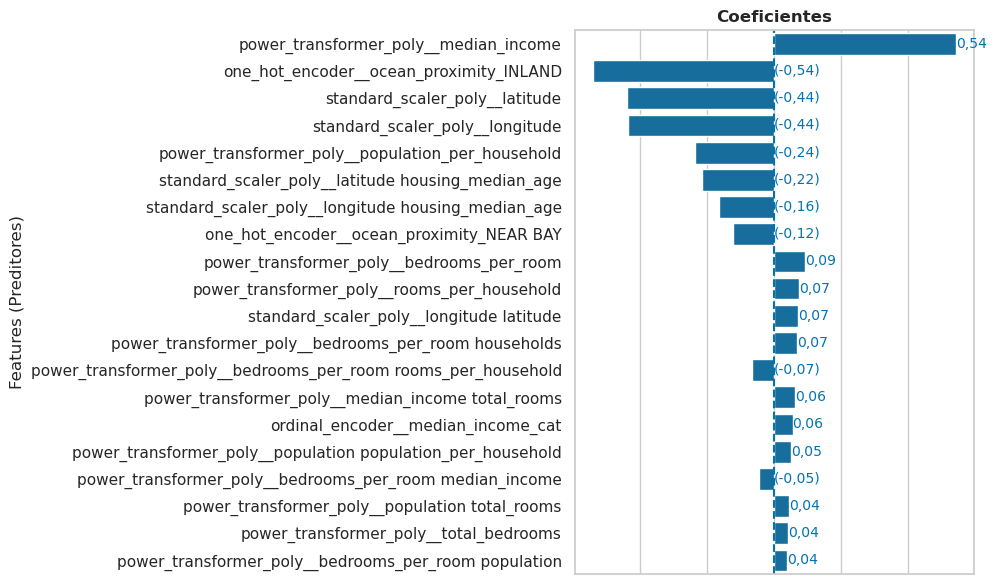

In [14]:
plot_coeficientes(df_coeficientes, precisao=2,)

Compararando com a etapa anterior, podemos ver que a transformação das variáveis foi capaz de trocar bastante a relevância das variáveis para o modelo, trocando bastante sua ordem.

Muitas features não tiveram contribuição para o novo modelo, ficando com coeficiente zero. O que não seria uma característica do `Ridge`, que será nosso próximo teste, sendo mais um indício de que a regularização não nos ajudará a encontrar um novo melhor modelo.

## Vamos comparar nosso novo modelo com os que tinhamos antes

In [15]:
# regressores atualizado com a melhor estratégia encontrada pelo GRID SEARCH
# apenas para comparar com o melhor modelo que sairá do grid search
regressors = {
    # Modelo incial simples apenas para comparação
    'LinearRegression_simples': {
        'preprocessor': preprocessamento_categoricas,
        'regressor': LinearRegression(),
        'target_transformer': None,
    },

    # melhor até o momento,
    'LinearRegression_melhor_atual': {
        'preprocessor': preprocessamento_polinomiais,
        'regressor': LinearRegression(),
        'target_transformer': target_transfomer
    },

    # novo modelo indicado como melhor após o GRID SEARCH
    'LinearRegression_best_estimator': {
        'preprocessor':       grid_search.best_estimator_.regressor_['preprocessor'],
        'regressor':          grid_search.best_estimator_.regressor_['regressor'],
        'target_transformer': grid_search.best_estimator_.transformer_,
    }
}

pprint(regressors)

{'LinearRegression_best_estimator': {'preprocessor': ColumnTransformer(transformers=[('one_hot_encoder', OneHotEncoder(drop='first'),
                                 ['ocean_proximity']),
                                ('ordinal_encoder', OrdinalEncoder(),
                                 ['median_income_cat', 'housing_median_age_cat',
                                  'population_cat']),
                                ('standard_scaler_poly',
                                 Pipeline(steps=(('standard_scaler',
                                                  StandardScaler()),
                                                 ('poly',
                                                  PolynomialFeatures(interaction_only=True)))),
                                 ['longitude', 'latitude',
                                  'housing_median_age']),
                                ('power_transformer_poly',
                                 Pipeline(steps=(('power_transformer',
          

In [16]:
df_resultados = fnc_treinar_e_validar_modelos_regressao(
    X=X_train,
    y=y_train,
    regressors=regressors,
    scoring=tuple(dct_metricas_modelos.keys()),
)

fnc_exibir_dataframe_resultados(df_resultados)

,model,fit_time,score_time,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,test_r2,time_seconds
0,LinearRegression_simples,0.048636,0.031320,-40752.245328,-55293.325335,0.649683,0.079956
1,LinearRegression_simples,0.026347,0.012594,-43153.132860,-65273.979368,0.537121,0.038940
2,LinearRegression_simples,0.023661,0.012700,-42344.177226,-58983.680481,0.625750,0.036361
3,LinearRegression_simples,0.024315,0.012946,-42839.980813,-58944.889944,0.635304,0.037261
4,LinearRegression_simples,0.024985,0.013148,-42373.880720,-58053.346421,0.625479,0.038133
5,LinearRegression_melhor_atual,0.966266,0.019952,-35668.069225,-49916.989623,0.714495,0.986218
6,LinearRegression_melhor_atual,0.983158,0.021485,-37278.410416,-53944.182640,0.683862,1.004643
7,LinearRegression_melhor_atual,1.156934,0.019598,-37095.143472,-52489.709971,0.703621,1.176532
8,LinearRegression_melhor_atual,1.091720,0.032640,-37239.988110,-53442.491431,0.700213,1.124360
9,LinearRegression_melhor_atual,1.346504,0.021116,-37742.240006,-53802.130300,0.678323,1.367621


In [17]:
fnc_exibir_dataframe_resultados(df_resultados.groupby('model').mean())

,fit_time,score_time,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,test_r2,time_seconds
model,,,,,,
LinearRegression_best_estimator,1.171485,0.020399,-37366.994094,-53241.384654,0.690062,1.191884
LinearRegression_melhor_atual,1.108917,0.022958,-37004.770246,-52719.100793,0.696103,1.131875
LinearRegression_simples,0.029589,0.016541,-42292.683389,-59309.844310,0.614667,0.046130


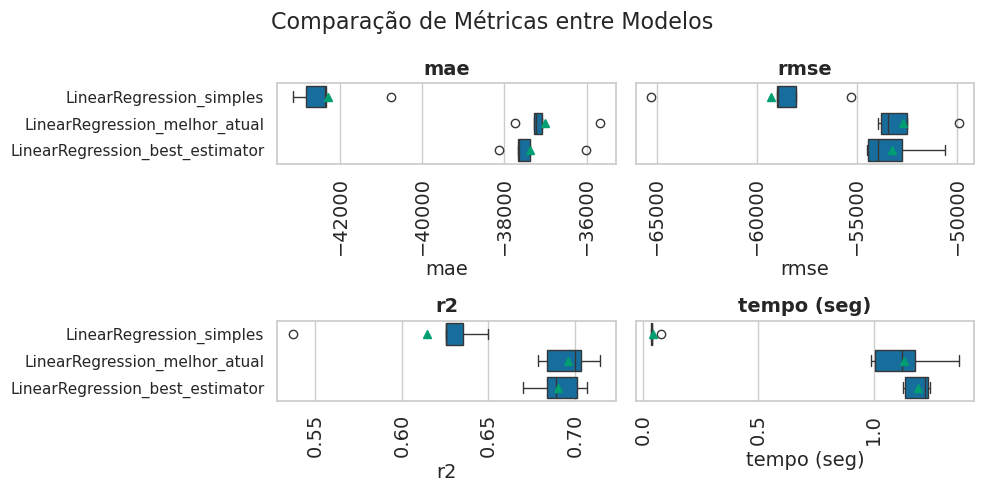

In [18]:
plot_comparar_metricas_modelos(
    df_resultados=df_resultados,
    comparar_metricas=['test_' + metrica for metrica in dct_metricas_modelos.keys()] + ['time_seconds'],
    nomes_metricas=list(dct_metricas_modelos.values()) + ['tempo (seg)'],
    figsize=(10, 5),
    colunas_graficos=2,
    flg_boxplots_horizontais=True,
)

### Sobre o novo modelo encontrado pelo GRID SEARCH
O novo modelo encontrado pelo GRID SEARCH não consegue vencer o nosso melhor modelo vindo da etapa anterior em nenhuma as métricas de avaliação selecionadas. Média e mediana claramente superiores no modelo anterior.

Vamos desconsiderar esse novo modelo e tentar na nova etapa uma segunda versão com regularização utilizando `Ridge`.

## Resíduos do modelo novo

### Resíduos sobre a base de teste
Essa base não participou do treinamento em nenhum momento e são novos para o modelo.

In [19]:
# dados já separados como X e y de teste
X_test = pd.read_parquet(DADOS_X_TEST)
y_test = pd.read_parquet(DADOS_Y_TEST)

print('X_test.shape', X_test.shape)
print('y_test.shape', y_test.shape)

X_test.shape (3639, 15)
y_test.shape (3639, 1)


In [20]:
df_residuos = pd.DataFrame()
df_residuos['residuos'] = y_test - grid_search.predict(X_test)

df_describe = fnc_describe_numericas_personalizado(
    df=df_residuos,
    flg_mostrar_dataframe=False,
    flg_retornar_dataframe=True,
    teste_normalidade='Kolmogorov-Smirnov'
)

df_describe[['dist_normal', 'pvalue', 'teste_normalidade', 'skewness', 'kurtosis',]].T

,residuos
dist_normal,False
pvalue,0
teste_normalidade,Kolmogorov-Smirnov
skewness,0.74
kurtosis,3.72


,min,LOWER,01%,25%,50%,75%,99%,UPPER,max,mean,std
residuos,-326158.939812,-104789.934805,-123932.591834,-26499.384766,-3675.778809,25694.316406,175285.204119,103984.866582,337043.763878,3488.092041,54197.742188


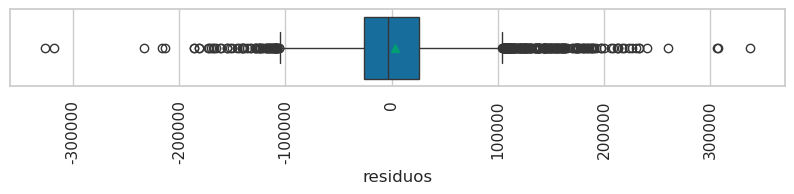

In [21]:
display(
    df_describe[['min', 'LOWER', '01%', '25%', '50%', '75%', '99%', 'UPPER', 'max', 'mean', 'std',
    ]].style.background_gradient(
        cmap=PALETTE_TEMPERATURA,
        axis='columns',
        subset=['min', 'LOWER', '01%', '25%', '50%', '75%', '99%', 'UPPER', 'max', 'mean',]
    )
)

# boxplot
fig, ax = plt.subplots(figsize=(10, 1))
sns.boxplot(
    data=df_residuos,
    x='residuos',
    showmeans=True,
    ax=ax,
)
# Definindo a orientação dos tick labels do eixo x na vertical
ax.set_xticklabels(
    labels=[int(x) for x in ax.get_xticks()],
    rotation=90,
)
plt.show()

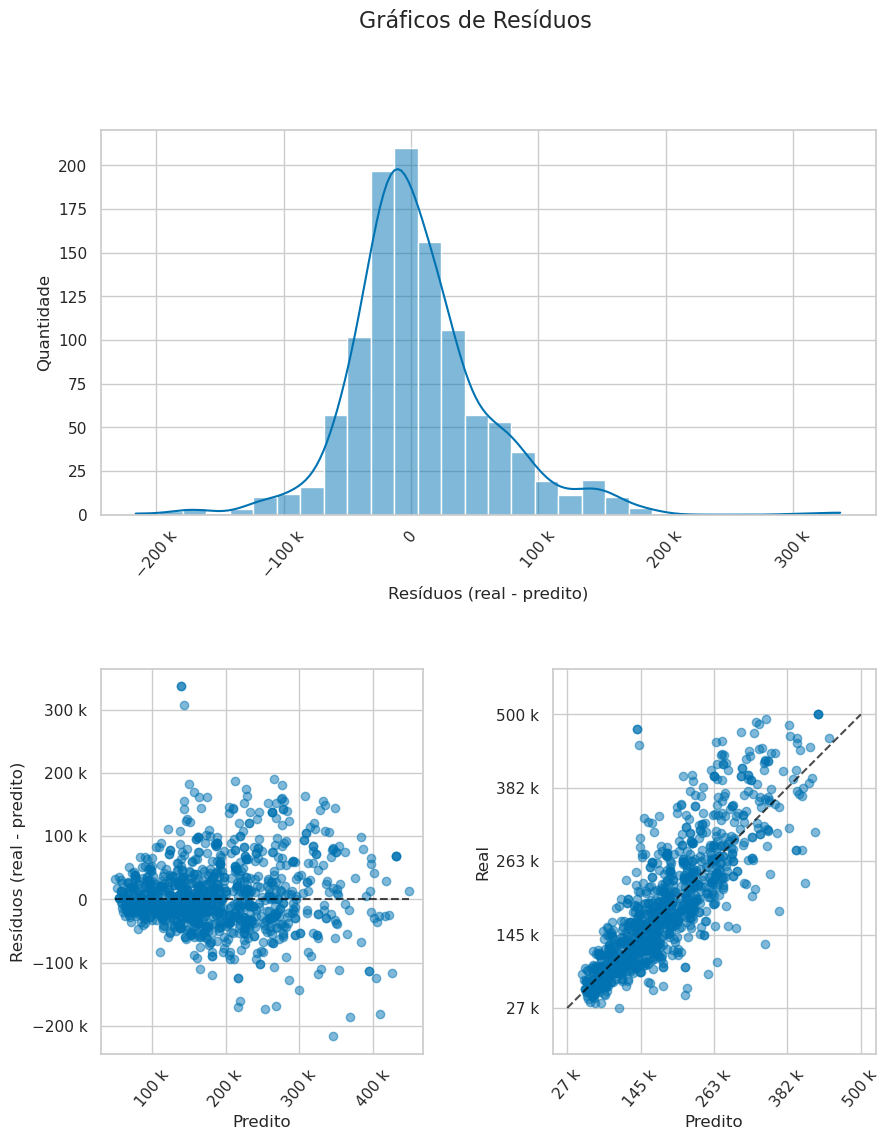

In [22]:
plot_residuos_estimador(grid_search.best_estimator_, X_test, y_test, fracao_amostra=0.3, eng_formatter=True) #, mosaico='bc;aa')

### Resíduos sobre a base de validação
Essa base não participou do treinamento em nenhum momento e são novos para o modelo.

In [23]:
y_validation = pd.read_parquet(DADOS_Y_VALIDATION)
X_validation = pd.read_parquet(DADOS_X_VALIDATION)

print('X_validation.shape', X_validation.shape)
print('y_validation.shape', y_validation.shape)

X_validation.shape (1874, 15)
y_validation.shape (1874, 1)


In [24]:
df_residuos = pd.DataFrame()
df_residuos['residuos'] = y_validation - grid_search.predict(X_validation)

df_describe = fnc_describe_numericas_personalizado(
    df=df_residuos,
    flg_mostrar_dataframe=False,
    flg_retornar_dataframe=True,
    teste_normalidade='Kolmogorov-Smirnov'
)

df_describe[['dist_normal', 'pvalue', 'teste_normalidade', 'skewness', 'kurtosis',]].T

,residuos
dist_normal,False
pvalue,0
teste_normalidade,Kolmogorov-Smirnov
skewness,1.05
kurtosis,4.42


,min,LOWER,01%,25%,50%,75%,99%,UPPER,max,mean,std
residuos,-255371.560771,-105055.632812,-106880.949147,-25774.034479,-1643.490112,27080.364245,193544.016626,106361.962331,360744.972152,4705.683594,55705.045002


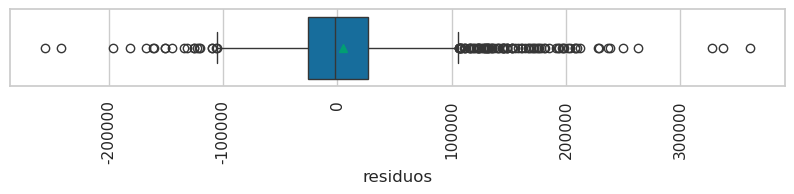

In [25]:
display(
    df_describe[['min', 'LOWER', '01%', '25%', '50%', '75%', '99%', 'UPPER', 'max', 'mean', 'std',
    ]].style.background_gradient(
        cmap=PALETTE_TEMPERATURA,
        axis='columns',
        subset=['min', 'LOWER', '01%', '25%', '50%', '75%', '99%', 'UPPER', 'max', 'mean',]
    )
)

# boxplot
fig, ax = plt.subplots(figsize=(10, 1))
sns.boxplot(
    data=df_residuos,
    x='residuos',
    showmeans=True,
    ax=ax,
)
# Definindo a orientação dos tick labels do eixo x na vertical
ax.set_xticklabels(
    labels=[int(x) for x in ax.get_xticks()],
    rotation=90,
)
plt.show()

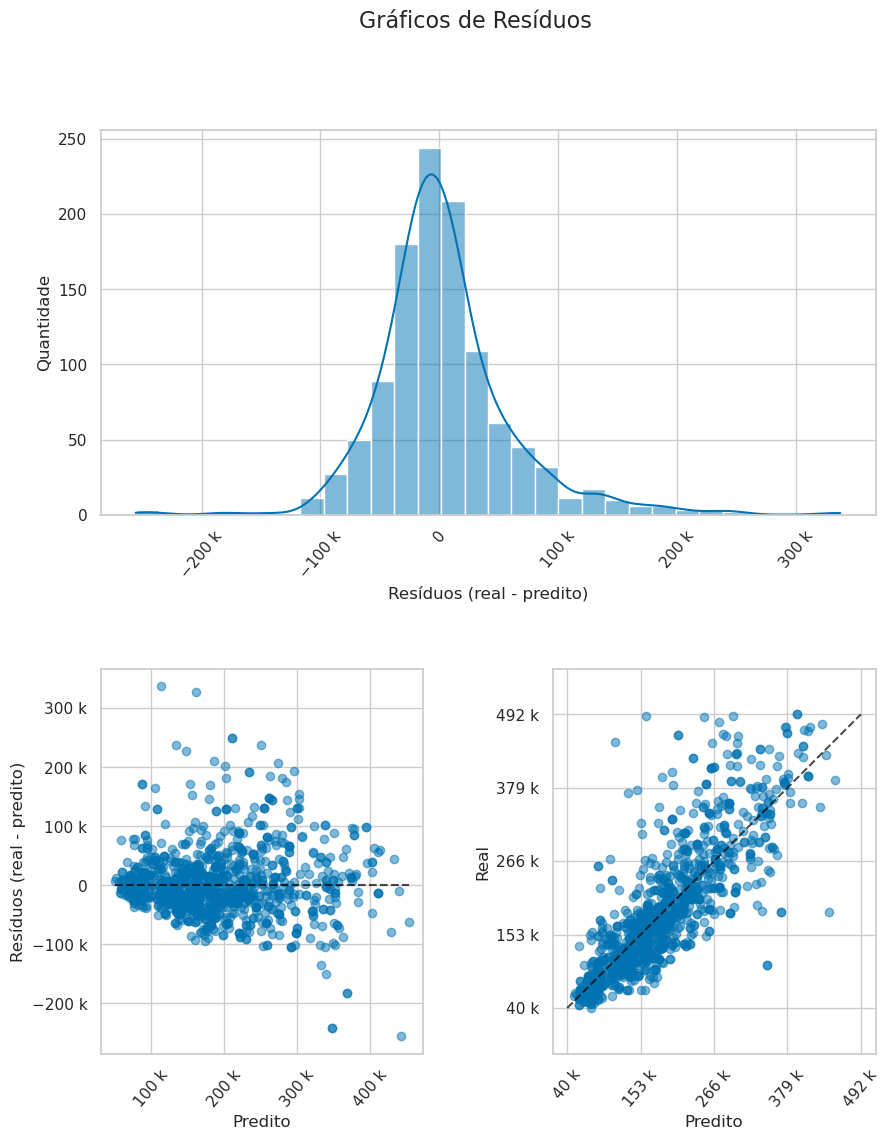

In [26]:
plot_residuos_estimador(grid_search.best_estimator_, X_validation, y_validation, fracao_amostra=0.6, eng_formatter=True) #, mosaico='bc;aa')

### Analisando os dados e gráficos de resíduos
Não podemos notar muita diferença entre nossos novos gráficos e os gráficos da etapa anterior.

Também é importante observar que não temos uma situação de overfitting, pois os dados de teste e validação não participaram do treinamento e ainda assim os resíduos estão próximos do que já conhecíamos de etapas anteriores.